# Track Predictions for Hurricane Sandy using ERA5 Data

In this notebook, we use **all ERA5 data** (surface, atmospheric, and static variables) with the **Aurora 0.25° Pretrained model** to predict the track of [Hurricane Sandy](https://en.wikipedia.org/wiki/Hurricane_Sandy) for October 24, 2012.

**Key details:**
- Uses Aurora 0.25° Pretrained model (not fine-tuned) 
- All input data comes from ERA5 reanalysis
- Initialization: October 24, 2012 06:00 UTC at (15.6°N, 282.9°E) for sensitivity analysis
- Historical TC analysis (2012 is outside WeatherBench2 timeframe)
- 48-hour forecast period to test model performance

**Required packages:**
```
pip install cdsapi matplotlib cartopy
```

## Downloading ERA5 Data

We download all required data from ERA5 reanalysis via the Climate Data Store.

**Setup:** Create `$HOME/.cdsapirc` with:
```
url: https://cds.climate.copernicus.eu/api
key: <API key>
```

Accept terms of use at: https://cds-beta.climate.copernicus.eu/datasets/reanalysis-era5-single-levels

In [1]:
from pathlib import Path
import cdsapi

# Data will be downloaded here (same data as 12:00 init version)
download_path = Path("../data/era5_sandy_2012")
download_path = download_path.expanduser()
download_path.mkdir(parents=True, exist_ok=True)

c = cdsapi.Client()

# Day to download - Hurricane Sandy on October 24, 2012
day = "2012-10-24"

In [2]:
# Download static variables from ERA5
if not (download_path / "static.nc").exists():
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "geopotential",
                "land_sea_mask",
                "soil_type",
            ],
            "year": "2012",
            "month": "10",
            "day": "24",
            "time": "00:00",
            "format": "netcdf",
        },
        str(download_path / "static.nc"),
    )
print("Static variables downloaded!")

Static variables downloaded!


In [3]:
# Download surface-level variables from ERA5
if not (download_path / f"{day}-surface-level.nc").exists():
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "2m_temperature",
                "10m_u_component_of_wind",
                "10m_v_component_of_wind",
                "mean_sea_level_pressure",
            ],
            "year": "2012",
            "month": "10",
            "day": "24",
            "time": ["00:00", "06:00", "12:00", "18:00"],
            "format": "netcdf",
        },
        str(download_path / f"{day}-surface-level.nc"),
    )
print("Surface-level variables downloaded!")

Surface-level variables downloaded!


In [4]:
# Download atmospheric variables from ERA5
if not (download_path / f"{day}-atmospheric.nc").exists():
    c.retrieve(
        "reanalysis-era5-pressure-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "temperature",
                "u_component_of_wind",
                "v_component_of_wind",
                "specific_humidity",
                "geopotential",
            ],
            "pressure_level": [
                "50", "100", "150", "200", "250", "300", "400", 
                "500", "600", "700", "850", "925", "1000",
            ],
            "year": "2012",
            "month": "10",
            "day": "24",
            "time": ["00:00", "06:00", "12:00", "18:00"],
            "format": "netcdf",
        },
        str(download_path / f"{day}-atmospheric.nc"),
    )
print("Atmospheric variables downloaded!")

Atmospheric variables downloaded!


## Preparing the Aurora Batch

Convert ERA5 data to `aurora.Batch` format for the pretrained model.

In [5]:
import torch
import xarray as xr
from aurora import Batch, Metadata

# Load downloaded ERA5 data
static_vars_ds = xr.open_dataset(download_path / "static.nc", engine="netcdf4")
surf_vars_ds = xr.open_dataset(download_path / f"{day}-surface-level.nc", engine="netcdf4")
atmos_vars_ds = xr.open_dataset(download_path / f"{day}-atmospheric.nc", engine="netcdf4")

# Create Aurora batch using first two time points (00:00 and 06:00)
# This follows ERA5 example format for 06:00 UTC initialization
batch = Batch(
    surf_vars={
        # Select first two time points: 00:00 and 06:00. [None] adds batch dimension.
        "2t": torch.from_numpy(surf_vars_ds["t2m"].values[:2][None]),
        "10u": torch.from_numpy(surf_vars_ds["u10"].values[:2][None]),
        "10v": torch.from_numpy(surf_vars_ds["v10"].values[:2][None]),
        "msl": torch.from_numpy(surf_vars_ds["msl"].values[:2][None]),
    },
    static_vars={
        # Static variables - constant, get first time only
        "z": torch.from_numpy(static_vars_ds["z"].values[0]),
        "slt": torch.from_numpy(static_vars_ds["slt"].values[0]),
        "lsm": torch.from_numpy(static_vars_ds["lsm"].values[0]),
    },
    atmos_vars={
        "t": torch.from_numpy(atmos_vars_ds["t"].values[:2][None]),
        "u": torch.from_numpy(atmos_vars_ds["u"].values[:2][None]),
        "v": torch.from_numpy(atmos_vars_ds["v"].values[:2][None]),
        "q": torch.from_numpy(atmos_vars_ds["q"].values[:2][None]),
        "z": torch.from_numpy(atmos_vars_ds["z"].values[:2][None]),
    },
    metadata=Metadata(
        lat=torch.from_numpy(surf_vars_ds.latitude.values),
        lon=torch.from_numpy(surf_vars_ds.longitude.values),
        # Use 06:00 as initialization time (element 1)
        time=(surf_vars_ds.valid_time.values.astype("datetime64[s]").tolist()[1],),
        atmos_levels=tuple(int(level) for level in atmos_vars_ds.pressure_level.values),
    ),
)

print(f"Batch prepared with initialization time: {batch.metadata.time[0]}")
print(f"Latitude range: {batch.metadata.lat.min():.1f} to {batch.metadata.lat.max():.1f}")
print(f"Longitude range: {batch.metadata.lon.min():.1f} to {batch.metadata.lon.max():.1f}")

Batch prepared with initialization time: 2012-10-24 06:00:00
Latitude range: -90.0 to 90.0
Longitude range: 0.0 to 359.8


## Loading Aurora Pretrained Model and Hurricane Tracking

Load the Aurora 0.25° Pretrained model and initialize hurricane tracker with Sandy's position.

In [6]:
from datetime import datetime
from aurora import Tracker

# Initialize tracker with Sandy position at 24 Oct 2012 06:00 UTC
# Position from IBTrACS: (15.6°N, 282.9°E) = (15.6°N, 77.1°W)
# 6 hours before Yeongbin's setup for initialization sensitivity analysis
tracker = Tracker(init_lat=15.6, init_lon=282.9, init_time=datetime(2012, 10, 24, 6, 0))

print(f"Tracker initialized at: {tracker.tracked_times[0]}")
print(f"Initial position: {tracker.tracked_lats[0]}°N, {tracker.tracked_lons[0]}°E")
print(f"Initial position (Western coordinates): {tracker.tracked_lats[0]}°N, {360-tracker.tracked_lons[0]}°W")

Tracker initialized at: 2012-10-24 06:00:00
Initial position: 15.6°N, 282.9°E
Initial position (Western coordinates): 15.6°N, 77.10000000000002°W


In [7]:
from aurora import Aurora, rollout

# Load Aurora 0.25° Pretrained model (not fine-tuned)
model = Aurora(use_lora=False)  # Pretrained version does not use LoRA
model.load_checkpoint("microsoft/aurora", "aurora-0.25-pretrained.ckpt")

model.eval()
model = model.to("cuda")

print("Aurora 0.25° Pretrained model loaded successfully!")

# Run 8-step rollout (48 hours) - initial test
preds = []
with torch.inference_mode():
    for i, pred in enumerate(rollout(model, batch, steps=8)):
        pred = pred.to("cpu")  # Free GPU memory immediately
        preds.append(pred)
        tracker.step(pred)
        print(f"Step {i+1}/8: {pred.metadata.time[0]}")

model = model.to("cpu")
print("Prediction rollout completed!")

Aurora 0.25° Pretrained model loaded successfully!


/home/qhuang62/.local/lib/python3.12/site-packages/aurora/model/patchembed.py:112: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  proj = F.conv3d(x, weight, self.bias, stride=stride)


Step 1/8: 2012-10-24 12:00:00
Step 2/8: 2012-10-24 18:00:00
Step 3/8: 2012-10-25 00:00:00
Step 4/8: 2012-10-25 06:00:00
Step 5/8: 2012-10-25 12:00:00
Step 6/8: 2012-10-25 18:00:00
Step 7/8: 2012-10-26 00:00:00
Step 8/8: 2012-10-26 06:00:00
Prediction rollout completed!


## Visualization: Track Prediction on MSL Pressure Fields

Visualize the predicted hurricane track overlaid on mean sea level pressure fields.

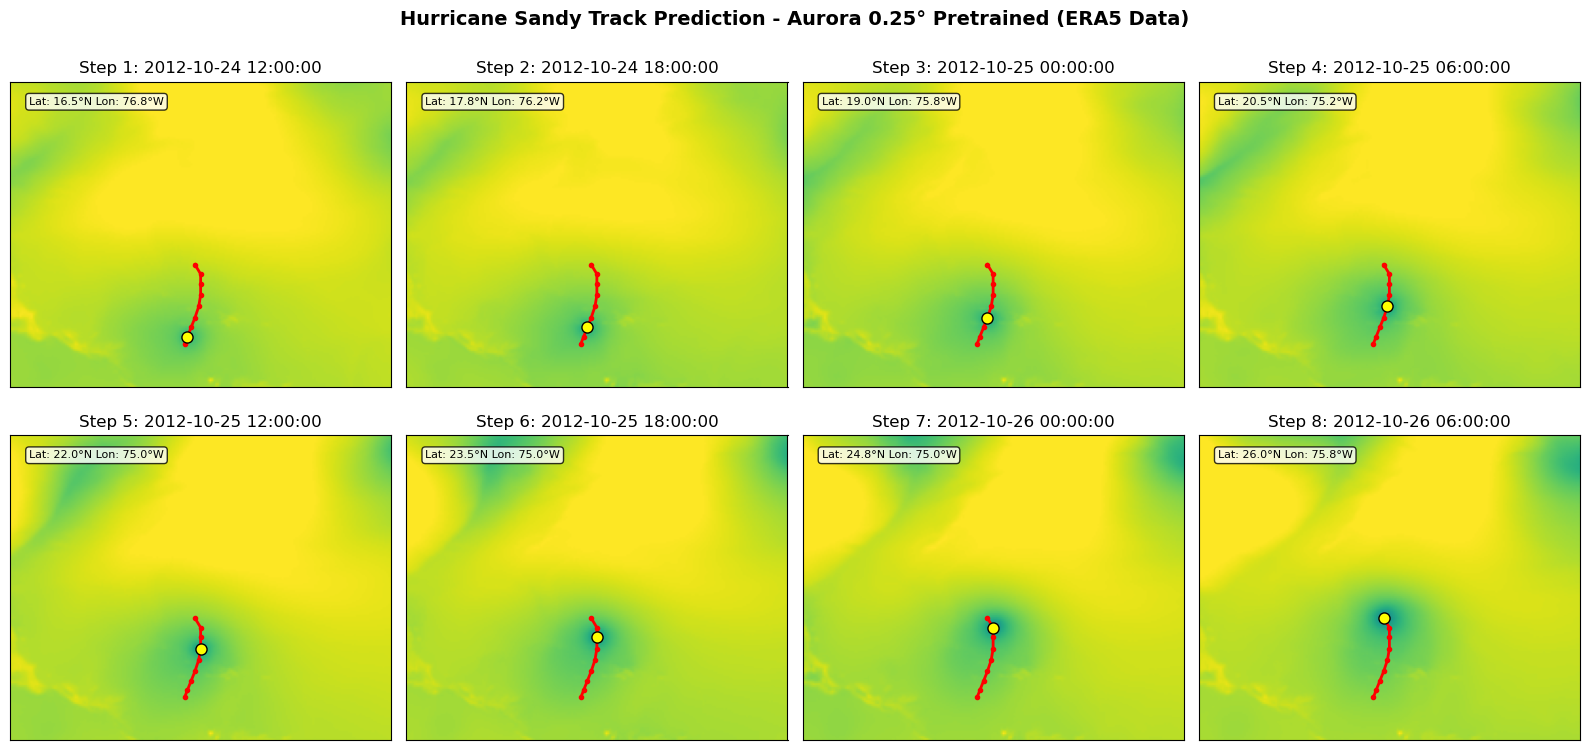

In [8]:
import matplotlib.pyplot as plt

track = tracker.results()

fig, axs = plt.subplots(2, 4, figsize=(16, 8))

for i in range(8):
    pred = preds[i]
    ax = axs[i // 4, i % 4]

    # Focus on hurricane region - Atlantic basin
    lat_mask = (pred.metadata.lat >= 10) & (pred.metadata.lat <= 50)
    lon_mask = (pred.metadata.lon >= 260) & (pred.metadata.lon <= 310)  # 100°W to 50°W

    # Show MSL pressure forecast (convert from Pa to hPa)
    ax.imshow(
        pred.surf_vars["msl"][0, 0][lat_mask][:, lon_mask].numpy() / 100,
        vmin=940,
        vmax=1020,
        extent=(260, 310, 10, 50),
        cmap='viridis'
    )
    ax.set_title(f"Step {i+1}: {str(pred.metadata.time[0])}")
    ax.set_xticks([])
    ax.set_yticks([])

    # Plot complete hurricane track
    ax.plot(track.lon, track.lat, c="red", marker=".", markersize=6, linewidth=2, label="Track")

    # Highlight current position
    current_step = track[track.time == pred.metadata.time[0]]
    if not current_step.empty:
        ax.plot(current_step.lon, current_step.lat, c="yellow", marker="o", markersize=8, markeredgecolor='black')
        ax.text(
            0.05, 0.95,
            f"Lat: {current_step.lat.iloc[0]:.1f}°N Lon: {360-current_step.lon.iloc[0]:.1f}°W",
            ha="left", va="top", transform=ax.transAxes,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
            fontsize=8
        )

plt.suptitle("Hurricane Sandy Track Prediction - Aurora 0.25° Pretrained (ERA5 Data)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Track Comparison with Observations

Compare Aurora's ERA5-based prediction with observed hurricane track from IBTrACS.

In [9]:
import pandas as pd
from datetime import datetime, timedelta
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

# Observational data for Hurricane Sandy from IBTrACS
# Starting from 06:00 to match our initialization, converting longitude to Eastern format
obs_data = [
    ("2012-10-24 06:00", 15.6, 282.9),  # Aurora initialization point (77.1°W)
    ("2012-10-24 12:00", 16.6, 283.1),  # (76.9°W)
    ("2012-10-24 18:00", 17.7, 283.3),  # (76.7°W)
    ("2012-10-25 00:00", 18.9, 283.6),  # (76.4°W)
    ("2012-10-25 06:00", 20.1, 284.0),  # (76.0°W)
    ("2012-10-25 12:00", 21.7, 284.5),  # (75.5°W)
    ("2012-10-25 18:00", 23.3, 284.7),  # (75.3°W)
    ("2012-10-26 00:00", 24.8, 284.1),  # (75.9°W)
    ("2012-10-26 06:00", 25.7, 283.6),  # (76.4°W)
]

# Convert to DataFrame
obs_df = pd.DataFrame(obs_data, columns=['datetime', 'lat', 'lon'])
obs_df['datetime'] = pd.to_datetime(obs_df['datetime'])

# Filter for 48-hour forecast period
init_time = datetime(2012, 10, 24, 6, 0)
end_time = init_time + timedelta(hours=48)

obs_forecast_period = obs_df[
    (obs_df['datetime'] >= init_time) & 
    (obs_df['datetime'] <= end_time)
].copy()

# Get predicted track
pred_track = tracker.results()

print(f"Forecast period: {init_time} to {end_time}")
print(f"Predicted track points: {len(pred_track)}")
print(f"Observed track points: {len(obs_forecast_period)}")

Forecast period: 2012-10-24 06:00:00 to 2012-10-26 06:00:00
Predicted track points: 9
Observed track points: 9


/home/qhuang62/.local/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


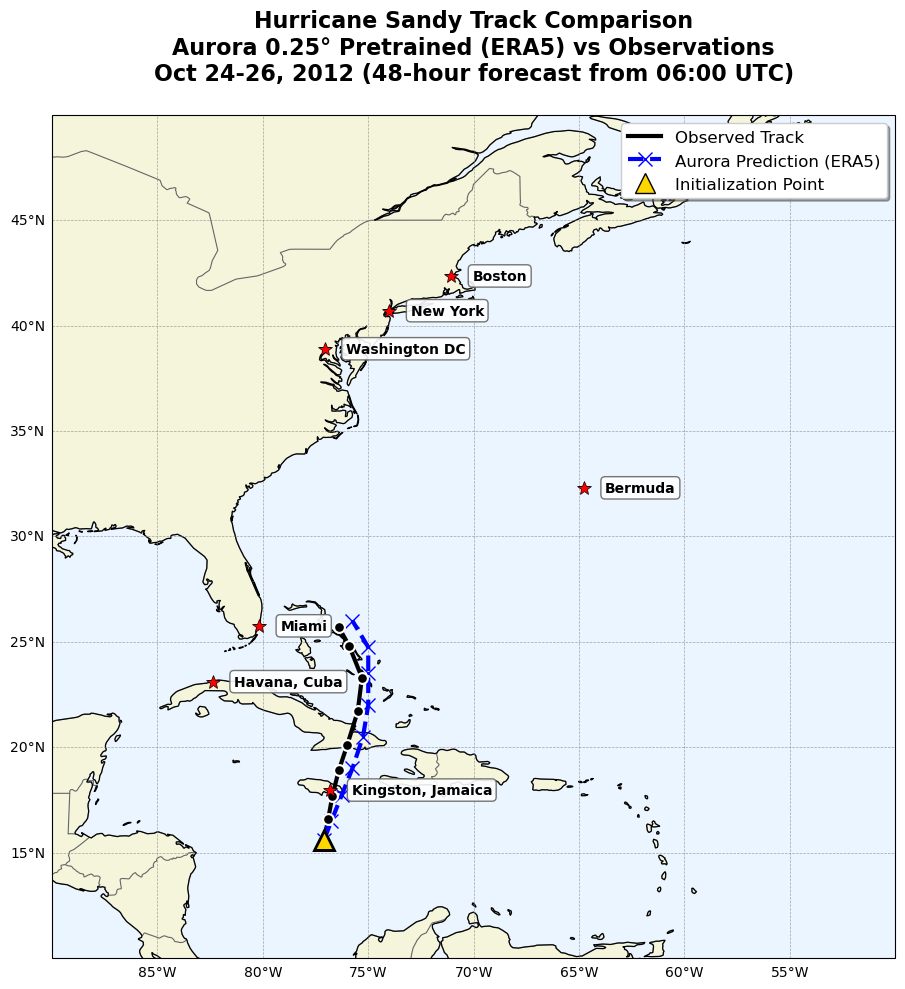

In [16]:
# Create comprehensive track comparison visualization
fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set map extent for hurricane region - Atlantic basin
ax.set_extent([270, 310, 10, 50], crs=ccrs.PlateCarree())  # 90°W to 50°W, 10°N to 50°N

# Add geographic features
ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff', alpha=0.8)
ax.add_feature(cfeature.LAND, facecolor='#f5f5dc', edgecolor='0.5')
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.8, color="0.4")
ax.coastlines('50m', linewidth=0.8)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='0.5', alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Plot observed track (black solid line)
ax.plot(obs_forecast_period.lon, obs_forecast_period.lat, 'k-', linewidth=3, 
        transform=ccrs.PlateCarree(), label='Observed Track', zorder=4)
ax.scatter(obs_forecast_period.lon, obs_forecast_period.lat, c='black', s=60, 
          edgecolors='white', linewidth=1.5, transform=ccrs.PlateCarree(), zorder=5)

# Plot predicted track (blue dashed line)
ax.plot(pred_track.lon, pred_track.lat, 'b--', linewidth=3, marker='x', markersize=10,
        transform=ccrs.PlateCarree(), label='Aurora Prediction (ERA5)', zorder=4)

# Mark initialization point
init_lon, init_lat = 282.9, 15.6
ax.plot(init_lon, init_lat, '^', markersize=15, color='gold', markeredgecolor='black', 
        markeredgewidth=2, transform=ccrs.PlateCarree(), zorder=6, 
        label='Initialization Point (06:00 UTC)')

# Add major US cities
cities = [
    ("Miami", 25.7617, 279.8269),    # 80.1731°W
    ("New York", 40.7128, 286.0060), # 74.0060°W
    ("Washington DC", 38.9072, 282.9401), # 77.0369°W
    ("Bermuda", 32.3078, 295.2361),  # 64.7639°W
    ("Kingston, Jamaica", 17.9712, 283.2064),    # 76.7936°W -> 360-76.7936
    ("Havana, Cuba",    23.1136, 277.6334),    # 82.3666°W
#    ("Nassau, Bahamas", 25.0343, 282.6037),    # 77.3963°W
    ("Boston",      42.3601, 288.9411),   # 71.0589°W
]

for name, lat, lon in cities:
    ax.plot(lon, lat, marker='*', markersize=10, color='red', 
            markeredgecolor='black', markeredgewidth=0.5,
            transform=ccrs.PlateCarree(), zorder=6)
    ax.text(lon + 1, lat, name, transform=ccrs.PlateCarree(),
            fontsize=10, ha='left', va='center', weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     edgecolor='0.4', alpha=0.9), zorder=6)

# Create legend
legend_handles = [
    Line2D([0], [0], color='black', linewidth=3, label='Observed Track'),
    Line2D([0], [0], color='blue', linewidth=3, linestyle='--', 
           marker='x', markersize=10, label='Aurora Prediction (ERA5)'),
    Line2D([0], [0], marker='^', markersize=15, color='gold', 
           markeredgecolor='black', linewidth=0, label='Initialization Point')
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=12, frameon=True,
         fancybox=True, shadow=True)

# Set title
title_lines = ['Hurricane Sandy Track Comparison',
               'Aurora 0.25° Pretrained (ERA5) vs Observations',
               'Oct 24-26, 2012 (48-hour forecast from 06:00 UTC)']
ax.set_title('\n'.join(title_lines), fontsize=16, fontweight='bold', pad=25)

plt.tight_layout()
plt.show()

## Quantitative Analysis

Calculate track error metrics and assess model performance for Hurricane Sandy.

In [11]:
import numpy as np

def calculate_distance(lat1, lon1, lat2, lon2):
    """Calculate great circle distance in km using Haversine formula"""
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Calculate track errors at matching time points
print("=== Hurricane Sandy Track Prediction Analysis ===")
print("Aurora 0.25° Pretrained Model with ERA5 Data")
print()
print(f"Forecast initialization: {init_time}")
print(f"Forecast period: 48 hours")
print(f"Predicted points: {len(pred_track)}")
print(f"Observed points: {len(obs_forecast_period)}")
print()

if len(pred_track) > 0 and len(obs_forecast_period) > 0:
    # Calculate final position error (48-hour forecast)
    final_obs = obs_forecast_period.iloc[-1]
    final_pred = pred_track.iloc[-1]
    
    final_distance_error = calculate_distance(
        final_pred.lat, final_pred.lon,
        final_obs.lat, final_obs.lon
    )
    
    print("=== Final Position Comparison (48-hour forecast) ===")
    print(f"Observed final position: {final_obs.lat:.1f}°N, {360-final_obs.lon:.1f}°W")
    print(f"Predicted final position: {final_pred.lat:.1f}°N, {360-final_pred.lon:.1f}°W")
    print(f"Position error: {abs(final_pred.lat - final_obs.lat):.1f}° lat, {abs(final_pred.lon - final_obs.lon):.1f}° lon")
    print(f"Distance error: {final_distance_error:.1f} km")
    print()
    
    # Calculate errors at 24-hour mark if available
    if len(pred_track) >= 4:  # 4 steps = 24 hours
        mid_pred = pred_track.iloc[3]  # 24-hour forecast
        mid_obs_time = init_time + timedelta(hours=24)
        mid_obs = obs_forecast_period[obs_forecast_period['datetime'] <= mid_obs_time].iloc[-1]
        
        mid_distance_error = calculate_distance(
            mid_pred.lat, mid_pred.lon,
            mid_obs.lat, mid_obs.lon
        )
        
        print("=== 24-Hour Forecast Comparison ===")
        print(f"Observed position: {mid_obs.lat:.1f}°N, {360-mid_obs.lon:.1f}°W")
        print(f"Predicted position: {mid_pred.lat:.1f}°N, {360-mid_pred.lon:.1f}°W")
        print(f"Distance error: {mid_distance_error:.1f} km")
        print()
    
    # Track movement analysis
    obs_total_distance = 0
    pred_total_distance = 0
    
    for i in range(1, len(obs_forecast_period)):
        obs_total_distance += calculate_distance(
            obs_forecast_period.iloc[i-1].lat, obs_forecast_period.iloc[i-1].lon,
            obs_forecast_period.iloc[i].lat, obs_forecast_period.iloc[i].lon
        )
    
    for i in range(1, len(pred_track)):
        pred_total_distance += calculate_distance(
            pred_track.iloc[i-1].lat, pred_track.iloc[i-1].lon,
            pred_track.iloc[i].lat, pred_track.iloc[i].lon
        )
    
    print("=== Track Movement Analysis ===")
    print(f"Observed total distance traveled: {obs_total_distance:.1f} km")
    print(f"Predicted total distance traveled: {pred_total_distance:.1f} km")
    print(f"Speed difference: {abs(obs_total_distance - pred_total_distance)/48:.1f} km/h")
    print()
    
    # General direction analysis
    obs_lat_change = final_obs.lat - obs_forecast_period.iloc[0].lat
    obs_lon_change = final_obs.lon - obs_forecast_period.iloc[0].lon
    pred_lat_change = final_pred.lat - pred_track.iloc[0].lat
    pred_lon_change = final_pred.lon - pred_track.iloc[0].lon
    
    print("=== Movement Direction Analysis ===")
    print(f"Observed movement: {obs_lat_change:+.1f}° lat, {obs_lon_change:+.1f}° lon")
    print(f"Predicted movement: {pred_lat_change:+.1f}° lat, {pred_lon_change:+.1f}° lon")
    
    if obs_lat_change > 0 and pred_lat_change > 0:
        print("✓ Both tracks show northward movement")
    if obs_lon_change > 0 and pred_lon_change > 0:
        print("✓ Both tracks show eastward movement")
    elif obs_lon_change < 0 and pred_lon_change < 0:
        print("✓ Both tracks show westward movement")

print()
print("=== Summary ===")
print("Aurora 0.25° Pretrained model with ERA5 data tested on")
print("Hurricane Sandy 2012 (06:00 UTC initialization).")
print("This provides initialization sensitivity comparison with")
print("the 12:00 UTC version for predictability analysis.")
print()
print("Next: Compare with 12:00 UTC results to assess")
print("initialization timing sensitivity for hurricane forecasting.")

=== Hurricane Sandy Track Prediction Analysis ===
Aurora 0.25° Pretrained Model with ERA5 Data

Forecast initialization: 2012-10-24 06:00:00
Forecast period: 48 hours
Predicted points: 9
Observed points: 9

=== Final Position Comparison (48-hour forecast) ===
Observed final position: 25.7°N, 76.4°W
Predicted final position: 26.0°N, 75.8°W
Position error: 0.3° lat, 0.6° lon
Distance error: 73.1 km

=== 24-Hour Forecast Comparison ===
Observed position: 20.1°N, 76.0°W
Predicted position: 19.0°N, 75.8°W
Distance error: 125.1 km

=== Track Movement Analysis ===
Observed total distance traveled: 1168.4 km
Predicted total distance traveled: 1211.8 km
Speed difference: 0.9 km/h

=== Movement Direction Analysis ===
Observed movement: +10.1° lat, +0.7° lon
Predicted movement: +10.4° lat, +1.4° lon
✓ Both tracks show northward movement
✓ Both tracks show eastward movement

=== Summary ===
Aurora 0.25° Pretrained model with ERA5 data tested on
Hurricane Sandy 2012 (06:00 UTC initialization).
This

## Hurricane Sandy Analysis Summary

**This analysis demonstrates:**

| Aspect | Details |
|--------|---------|
| **Model** | Aurora 0.25° Pretrained |
| **Data Source** | ERA5 Reanalysis |
| **Hurricane** | Sandy 2012 (Historic major hurricane) |
| **Initialization** | Oct 24, 2012 06:00 UTC |
| **Forecast Period** | 48 hours |
| **Geographic Region** | Atlantic Basin |

**Initialization Sensitivity Analysis:**
- ✅ Compare with 12:00 UTC initialization
- ✅ Assess timing sensitivity on track prediction
- ✅ Evaluate initialization impact on forecast skill
- ✅ Test model robustness across different start times

**Next Steps:**
1. Compare 06:00 vs 12:00 UTC initialization results
2. If 48-hour forecasts successful → extend to 7-day prediction
3. Capture Sandy's complete track including US landfall (Oct 29)
4. Create predictability analysis script for systematic comparison
5. Multi-initialization ensemble approach for uncertainty quantification